In [1]:
import psycopg2
import pandas as pd

In [2]:
db_params = {
    'host': '194.171.191.226',
    'port': '6379',
    'database': 'postgres',
    'user': 'group15',
    'password': 'blockd_2024group15_73'
}

In [3]:
conn_psycopg2 = psycopg2.connect(**db_params)
cursor = conn_psycopg2.cursor()

In [4]:
# Execute SQL query to fetch distinct category types
query = '''
    SELECT * 
    FROM group15_warehouse.accident_data_17_23
'''

cursor.execute(query)

# Fetch all rows
new_accident_rows = cursor.fetchall()

# Fetch column names
column_names = [desc[0] for desc in cursor.description]

# Convert the fetched data into a pandas DataFrame
new_accidents = pd.DataFrame(new_accident_rows, columns=column_names)

display(new_accidents)

,Year,Accident severity,municipality,town,First Mode of Transport,Second mode of Transport,Area Type,Light condition,Road Location,Road condition,Road surface,Road situation,Speed limit,street,weather,accidents
0,2017,Fatal,Breda,BREDA,Car,Pedestrian,Urban area,Darkness,Intersection,Wet/damp,Brick,Bend,30 km/h,Valkeniersplein,Rain,1
1,2017,Fatal,Breda,BREDA,Lorry,Other,Urban area,Daylight,Intersection,Wet/damp,Brick,Intersection - 4 arms,50 km/h,Markendaalseweg,Dry,1
2,2017,Fatal,Breda,BREDA,Lorry,Other,Urban area,Daylight,Road section,Dry,Asphalt (other),Straight road,50 km/h,Academiesingel,Dry,1
3,2017,Injured,Breda,BAVEL,Car,Lorry,Rural area,Darkness,Road section,Wet/damp,Asphalt (other),Bend,120 km/h,KP ST.ANNABOSCH,Dry,1
4,2017,Injured,Breda,BAVEL,Car,Other,Rural area,Darkness,Road section,Wet/damp,Porous asphalt,Straight road,130 km/h,RYKSWG,Rain,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6897,2023,Fatal,Breda,BREDA,Car,Moped,Urban area,Daylight,Road section,Dry,Asphalt (other),Straight road,50 km/h,Terheijdenseweg,Dry,1
6898,2023,Fatal,Breda,BREDA,Car,Car,Urban area,Darkness,Intersection,Dry,Asphalt (other),Intersection - 4 arms,70 km/h,Rijsbergseweg,Dry,1
6899,2023,Fatal,Breda,BREDA,Other,Other,Rural area,Daylight,Road section,Wet/damp,Porous asphalt,Straight road,100 km/h,RYKSWG,Dry,1
6900,2023,Fatal,Breda,PRINSENBEEK,Car,Car,Rural area,Darkness,Road section,Dry,Porous asphalt,Straight road,130 km/h,RYKSWG,Dry,1


<Axes: >

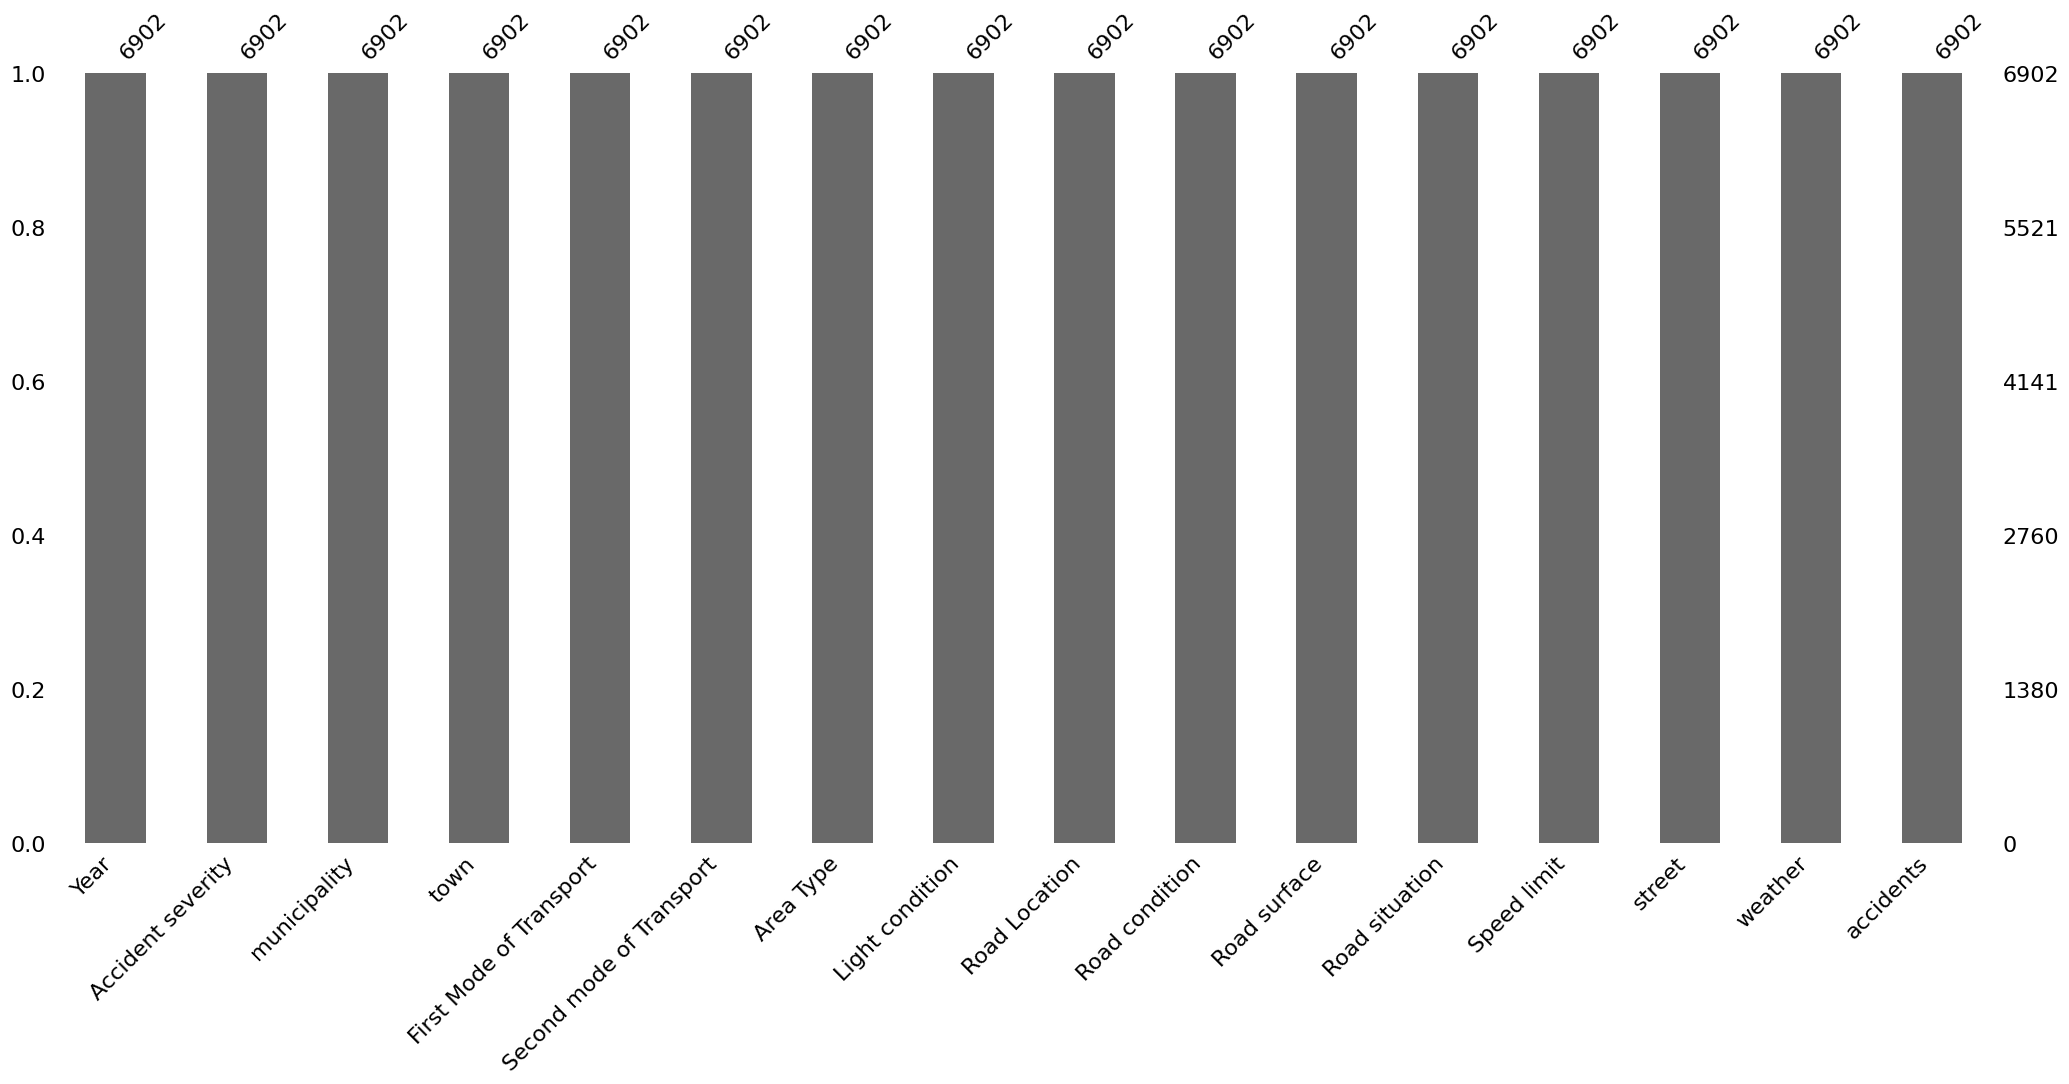

In [5]:
import psycopg2
import pandas as pd
import missingno as msno

# Visualize missing values using missingno
msno.bar(new_accidents)

In [6]:
# Print details of the dataset
print("\nData Types:")
print(new_accidents.info())


Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6902 entries, 0 to 6901
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Year                      6902 non-null   int64 
 1   Accident severity         6902 non-null   object
 2   municipality              6902 non-null   object
 3   town                      6902 non-null   object
 4   First Mode of Transport   6902 non-null   object
 5   Second mode of Transport  6902 non-null   object
 6   Area Type                 6902 non-null   object
 7   Light condition           6902 non-null   object
 8   Road Location             6902 non-null   object
 9   Road condition            6902 non-null   object
 10  Road surface              6902 non-null   object
 11  Road situation            6902 non-null   object
 12  Speed limit               6902 non-null   object
 13  street                    6902 non-null   object
 14  weather    

## Preprocessing steps

In [7]:
# Step 1: Handle Missing Values
# Check for missing values
missing_values = new_accidents.isnull().sum()
print("\Missing values:")
print(missing_values)

\Missing values:
Year                        0
Accident severity           0
municipality                0
town                        0
First Mode of Transport     0
Second mode of Transport    0
Area Type                   0
Light condition             0
Road Location               0
Road condition              0
Road surface                0
Road situation              0
Speed limit                 0
street                      0
weather                     0
accidents                   0
dtype: int64


In [8]:
# Step 2: Removing Duplicates
new_accidents.drop_duplicates(inplace=True)

In [9]:
# Step 3: Converting Categorical Variables
# Convert categorical variables to category type
categorical_cols = ['Accident severity', 'municipality', 'town', 'First Mode of Transport', 'Second mode of Transport',
                    'Area Type', 'Light condition', 'Road Location', 'Road condition', 'Road surface', 'Road situation',
                    'street', 'weather']

for col in categorical_cols:
    new_accidents[col] = new_accidents[col].astype('category')

In [10]:
# Step 4: Correcting Data Types
# Convert 'Speed limit' to numerical values, specifically integers
new_accidents['Speed limit'] = new_accidents['Speed limit'].str.replace(' km/h', '')
new_accidents['Speed limit'] = pd.to_numeric(new_accidents['Speed limit'], errors='coerce')

# Rename the column
new_accidents.rename(columns={'Speed limit': 'Speed limit km/h'}, inplace=True)

In [11]:
# Step 5: Normalizing/Standardizing Numerical Values
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
new_accidents[['Speed limit km/h']] = scaler.fit_transform(new_accidents[['Speed limit km/h']])

In [12]:
# Check the datatypes again
print("\nData Types:")
print(new_accidents.info())


Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6902 entries, 0 to 6901
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Year                      6902 non-null   int64   
 1   Accident severity         6902 non-null   category
 2   municipality              6902 non-null   category
 3   town                      6902 non-null   category
 4   First Mode of Transport   6902 non-null   category
 5   Second mode of Transport  6902 non-null   category
 6   Area Type                 6902 non-null   category
 7   Light condition           6902 non-null   category
 8   Road Location             6902 non-null   category
 9   Road condition            6902 non-null   category
 10  Road surface              6902 non-null   category
 11  Road situation            6902 non-null   category
 12  Speed limit km/h          5793 non-null   float64 
 13  street                    6902 non-

In [13]:
# Get value counts for each column
value_counts_per_column = {col: new_accidents[col].value_counts() for col in new_accidents.columns}

# Display the value counts for each column
for column, counts in value_counts_per_column.items():
    print(f"Value counts for column '{column}':")
    print(counts)
    print()

Value counts for column 'Year':
Year
2017    1274
2018    1224
2019    1181
2022    1146
2021    1084
2020     985
2023       8
Name: count, dtype: int64

Value counts for column 'Accident severity':
Accident severity
Material Damage Only    5916
Injured                  936
Fatal                     50
Name: count, dtype: int64

Value counts for column 'municipality':
municipality
Breda    6902
Name: count, dtype: int64

Value counts for column 'town':
town
BREDA          5935
PRINSENBEEK     416
BAVEL           296
TETERINGEN      139
ULVENHOUT       113
GALDER            2
ETTEN-LEUR        1
Name: count, dtype: int64

Value counts for column 'First Mode of Transport':
First Mode of Transport
Car              4350
-                 853
Delivery van      496
Moped             362
Lorry             240
Bicycle           181
Light-moped       166
Motorcycle        106
Other              83
Bus                37
Other vehicle      22
Pedestrian          6
Name: count, dtype: int64

Valu

In [14]:
# Step 6: Label encode categorical variables
# Label encode categorical columns
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for column in categorical_cols:
    le = LabelEncoder()
    new_accidents[column] = le.fit_transform(new_accidents[column])
    label_encoders[column] = le  # Store the label encoder for inverse transformation if needed

In [15]:
# Check the resulting DataFrame
print(new_accidents.head())

   Year  Accident severity  municipality  town  First Mode of Transport  \
0  2017                  0             0     1                        3   
1  2017                  0             0     1                        6   
2  2017                  0             0     1                        6   
3  2017                  1             0     0                        3   
4  2017                  1             0     0                        3   

   Second mode of Transport  Area Type  Light condition  Road Location  \
0                        10          2                0              0   
1                         8          2                1              0   
2                         8          2                1              1   
3                         5          0                0              1   
4                         8          0                0              1   

   Road condition  Road surface  Road situation  Speed limit km/h  street  \
0               3          

In [16]:
# Step 7: Handling Outliers
# Using IQR for outlier detection
Q1 = new_accidents['Speed limit km/h'].quantile(0.25)
Q3 = new_accidents['Speed limit km/h'].quantile(0.75)
IQR = Q3 - Q1
outliers = (new_accidents['Speed limit km/h'] < (Q1 - 1.5 * IQR)) | (new_accidents['Speed limit km/h'] > (Q3 + 1.5 * IQR))

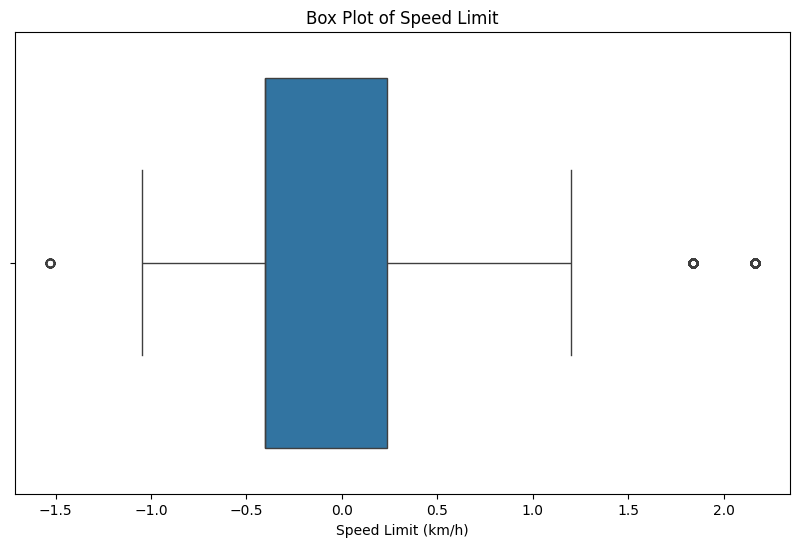

In [17]:
# Visualize outliers with a box plot
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(x=new_accidents['Speed limit km/h'])
plt.title('Box Plot of Speed Limit')
plt.xlabel('Speed Limit (km/h)')
plt.show()

In [18]:
# Print outliers
outlier_data = new_accidents[outliers]
print("Outliers in 'Speed limit':")
print(outlier_data)

Outliers in 'Speed limit':
      Year  Accident severity  municipality  town  First Mode of Transport  \
3     2017                  1             0     0                        3   
4     2017                  1             0     0                        3   
12    2017                  1             0     1                        5   
31    2017                  1             0     1                        8   
48    2017                  1             0     1                        3   
...    ...                ...           ...   ...                      ...   
6844  2022                  2             0     4                        4   
6853  2022                  2             0     4                        9   
6854  2022                  2             0     4                        9   
6855  2022                  2             0     4                        9   
6900  2023                  0             0     4                        3   

      Second mode of Transport  Area